# 1. Аналіз даних для дипломної роботи

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, Polygon
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# Константи для аналізу ефективності доставки

PROBLEM_THRESHOLD     = 180   # хв — граничний час доставки за SLA
RISK_THRESHOLD        = 120   # хв — поріг зони ризику
CRITICAL_THRESHOLD    = 240   # хв — поріг критичної затримки
COURIER_HOUR_RATE_USD = 2.5   # вартість години роботи кур'єра, USD
OPTIMIZATION_RATE     = 0.15  # цільове скорочення часу доставки (15%)
OPTIMIZATION_FACTOR   = 1 - OPTIMIZATION_RATE

# Visual theme
sns.set_theme(style="whitegrid")

# 2.1 Характеристика бази даних LaDe та підготовка аналітичних даних

### Для проведення аналізу було використано відкриту базу даних LaDe, що містить інформацію про реальні кур'єрські доставки у містах Ханчжоу, Шанхай та Чунцін. 
### На етапі підготовки даних виконано очищення датасету, обробку часових міток, розрахунок тривалості доставки та формування додаткових аналітичних показників.

In [3]:
# Завантаження, очищення та підготовка даних для подальшого аналізу

df = pd.read_csv("delivery_five_cities.csv")
df = df.drop_duplicates()

# Переклад назв міст та формування стандартизованого довідника локацій
city_translation = {"杭州市": "Hangzhou", "上海市": "Shanghai", "重庆市": "Chongqing"}
df["city"] = df["from_city_name"].map(city_translation)
df = df[df["city"].notna()].copy()

# Перетворення часових міток та розрахунок тривалості доставки
df["receipt_datetime"] = pd.to_datetime("2024-" + df["receipt_time"], errors="coerce")
df["sign_datetime"]    = pd.to_datetime("2024-" + df["sign_time"], errors="coerce")
df["delivery_duration_min"] = (
    df["sign_datetime"] - df["receipt_datetime"]
).dt.total_seconds() / 60

# Видалення записів з некоректною тривалістю доставки
df = df[df["delivery_duration_min"].between(0, 1440)].copy()

# Нормалізація географічних координат для подальшого аналізу
for prefix in ("receipt", "poi"):
    df[f"{prefix}_lng_clean"] = df[f"{prefix}_lng"] / 100_000
    df[f"{prefix}_lat_clean"] = df[f"{prefix}_lat"] / 100_000

# Формування додаткових операційних показників
df["receipt_hour"] = df["receipt_datetime"].dt.hour
df["is_problem_delivery"] = df["delivery_duration_min"] > PROBLEM_THRESHOLD
df["delivery_cost_usd"] = df["delivery_duration_min"] / 60 * COURIER_HOUR_RATE_USD

# Розрахунок тривалості та вартості затримок відносно нормативу SLA
df["delay_minutes"] = np.where(
    df["delivery_duration_min"] > PROBLEM_THRESHOLD,
    df["delivery_duration_min"] - PROBLEM_THRESHOLD,
    0
)
df["delay_cost_usd"] = df["delay_minutes"] / 60 * COURIER_HOUR_RATE_USD

# Групування доставок за часовими інтервалами
time_bins = [0, 60, 120, 180, 240, float("inf")]
time_labels = ["≤ 60 хв", "60–120 хв", "120–180 хв", "180–240 хв", "> 240 хв"]

df["time_group"] = pd.cut(
    df["delivery_duration_min"],
    bins=time_bins,
    labels=time_labels,
    right=True
)

# Формування сценарію оптимізації часу доставки
df_opt = df.copy()

df_opt["optimized_delivery_time"] = (
    df_opt["delivery_duration_min"] * OPTIMIZATION_FACTOR
)

df_opt["optimized_delivery_cost_usd"] = (
    df_opt["optimized_delivery_time"] / 60 * COURIER_HOUR_RATE_USD
)

# Розрахунок очікуваних затримок після впровадження оптимізації
df_opt["optimized_delay_minutes"] = np.where(
    df_opt["optimized_delivery_time"] > PROBLEM_THRESHOLD,
    df_opt["optimized_delivery_time"] - PROBLEM_THRESHOLD,
    0
)

# Формування загальної характеристики підготовленого датасету
overview = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique orders",
        "Unique couriers",
        "Cities",
        "Memory, MB"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df["order_id"].nunique(),
        df["delivery_user_id"].nunique(),
        df["city"].nunique(),
        round(df.memory_usage(deep=True).sum() / 1024**2, 2)
    ]
})

display(overview)

,Metric,Value
0,Rows,465384.0
1,Columns,29.0
2,Unique orders,465384.0
3,Unique couriers,1847.0
4,Cities,3.0
5,"Memory, MB",364.0


# 2.2 Статистичний аналіз часу доставки та виявлення системних проблем

## Для оцінки ефективності транспортно-технологічного процесу проведено порівняльний аналіз міст за обсягом доставок, середнім часом доставки та часткою проблемних замовлень.

,city,total_deliveries,mean_time_min,median_time_min,problem_share_pct
1,Hangzhou,184346,127.6,92.0,19.2
2,Shanghai,165048,96.5,74.0,10.5
0,Chongqing,115990,192.6,138.0,37.4


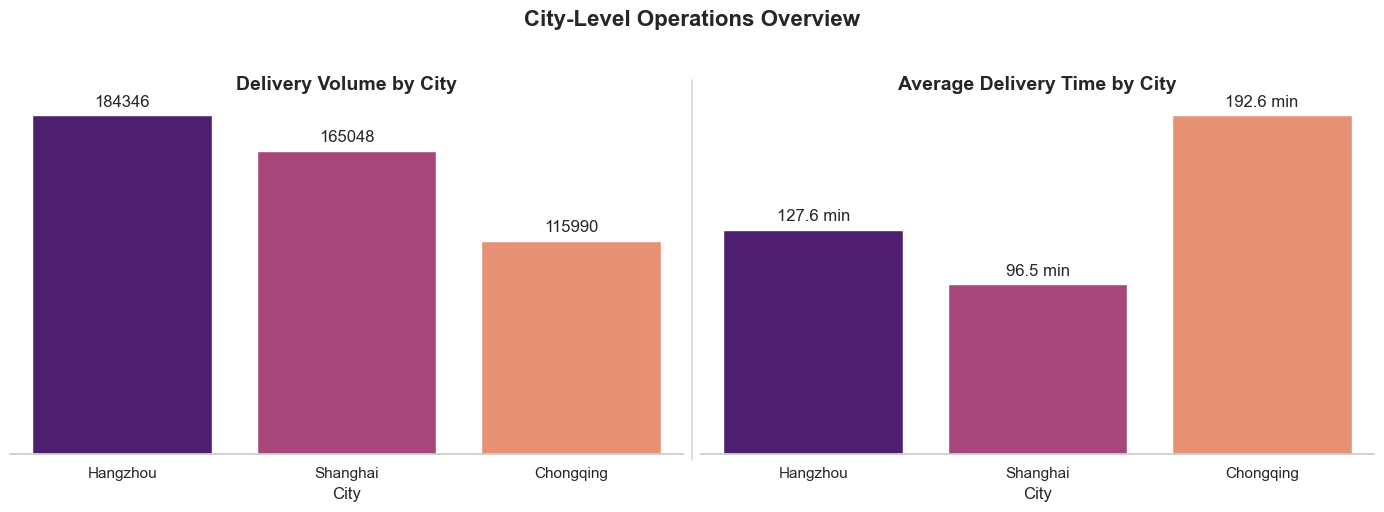

In [ ]:
from matplotlib.lines import Line2D

city_summary = (
    df.groupby("city")
    .agg(
        total_deliveries=("order_id", "count"),
        mean_time_min=("delivery_duration_min", "mean"),
        median_time_min=("delivery_duration_min", "median"),
        problem_share_pct=("is_problem_delivery", "mean")
    )
    .reset_index()
)

city_summary["mean_time_min"] = city_summary["mean_time_min"].round(1)
city_summary["median_time_min"] = city_summary["median_time_min"].round(1)
city_summary["problem_share_pct"] = (
    city_summary["problem_share_pct"] * 100
).round(1)

city_summary = city_summary.sort_values(
    "total_deliveries",
    ascending=False
)

display(city_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    ax.set_facecolor("white")
    ax.grid(False)

    ax.set_ylabel("")
    ax.set_yticks([])
   
    ax.spines["left"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)


# Кількість доставок

sns.barplot(
    data=city_summary,
    x="city",
    y="total_deliveries",
    palette="magma",
    ax=axes[0]
)

for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.0f", padding=4)

axes[0].set_title(
    "Delivery Volume by City",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("City")


# Середній час доставки

sns.barplot(
    data=city_summary,
    x="city",
    y="mean_time_min",
    palette="magma",
    ax=axes[1]
)

for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.1f min", padding=4)

axes[1].set_title(
    "Average Delivery Time by City",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("City")


fig.add_artist(
    Line2D(
        [0.5, 0.5],
        [0.12, 0.88],
        transform=fig.transFigure,
        color="#d9d9d9",
        linewidth=1.2
    )
)

plt.suptitle(
    "City-Level Operations Overview",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

# Аналіз розподілу тривалості доставки

## На цьому етапі досліджується розподіл часу виконання доставок та визначається, яка частина замовлень перебуває в межах нормативного порогу SLA. Для кращої візуалізації основної частини розподілу з аналізу графіка виключено 5% найбільш тривалих доставок.

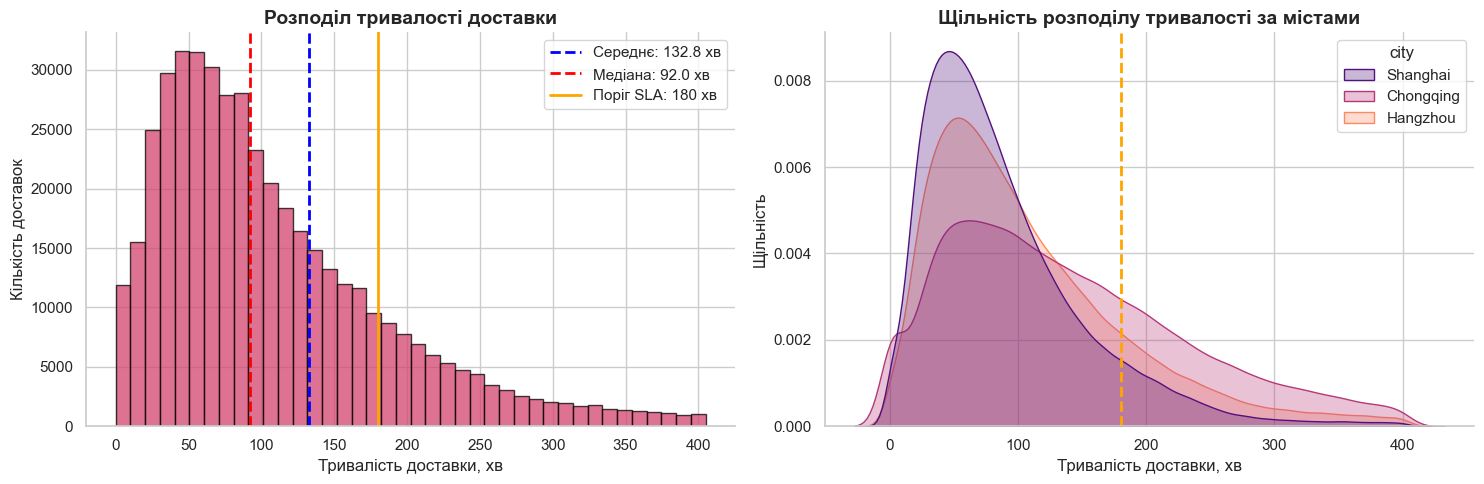

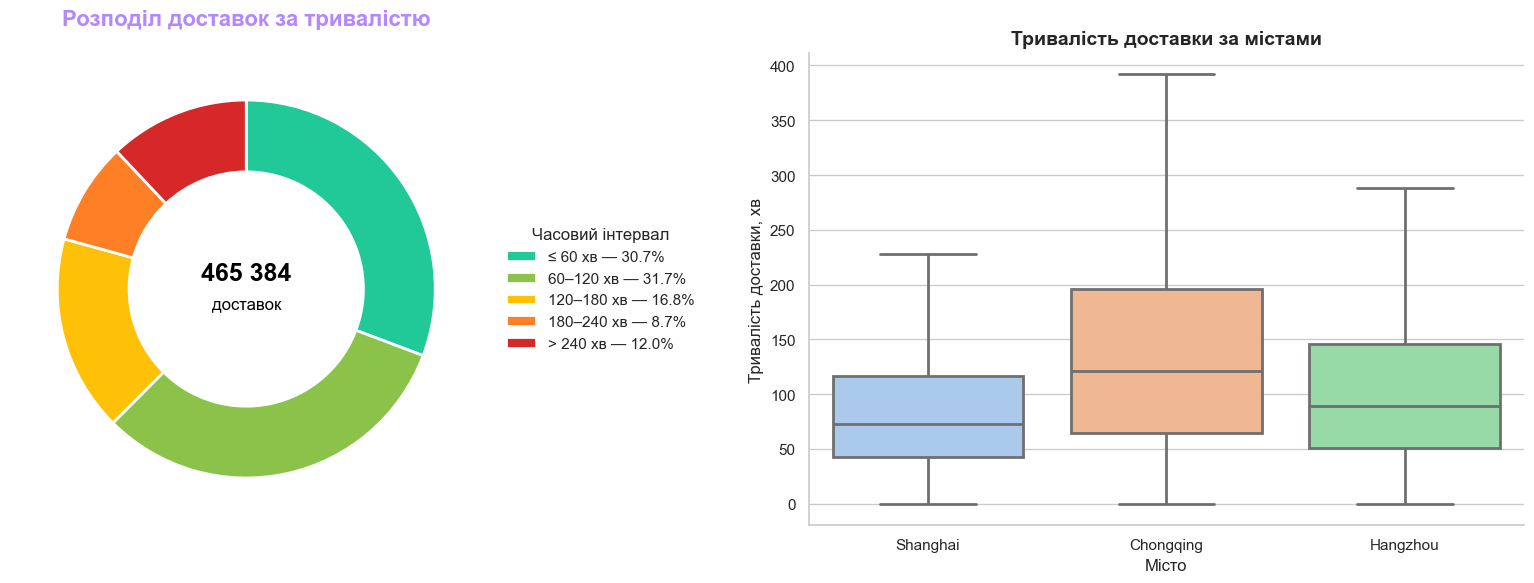

In [5]:
plot_data = df[
    df["delivery_duration_min"] <= df["delivery_duration_min"].quantile(0.95)
].copy()

mean_time = df["delivery_duration_min"].mean()
median_time = df["delivery_duration_min"].median()

# Побудова гістограми та KDE-графіка щільності розподілу

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Гістограма розподілу тривалості доставки
axes[0].hist(
    plot_data["delivery_duration_min"],
    bins=40,
    color=sns.color_palette("magma")[3],
    edgecolor="black",
    alpha=0.75
)

axes[0].axvline(mean_time, color="blue", linestyle="--", lw=2, label=f"Середнє: {mean_time:.1f} хв")
axes[0].axvline(median_time, color="red", linestyle="--", lw=2, label=f"Медіана: {median_time:.1f} хв")
axes[0].axvline(PROBLEM_THRESHOLD, color="orange", linestyle="-", lw=2, label=f"Поріг SLA: {PROBLEM_THRESHOLD} хв")

axes[0].set_title("Розподіл тривалості доставки", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Тривалість доставки, хв")
axes[0].set_ylabel("Кількість доставок")
axes[0].legend()
sns.despine(ax=axes[0])

# KDE-графік щільності розподілу за містами
sns.kdeplot(
    data=plot_data,
    x="delivery_duration_min",
    hue="city",
    fill=True,
    common_norm=False,
    alpha=0.3,
    palette="magma",
    ax=axes[1]
)

axes[1].axvline(PROBLEM_THRESHOLD, color="orange", linestyle="--", lw=2, label="Поріг SLA")
axes[1].set_title("Щільність розподілу тривалості за містами", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Тривалість доставки, хв")
axes[1].set_ylabel("Щільність")
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()


# Побудова кільцевої діаграми та boxplot-діаграми

time_distribution = (
    df["time_group"]
    .value_counts(normalize=True)
    .reindex(time_labels)
    .mul(100)
    .round(1)
)

donut_colors = ["#20c997", "#8bc34a", "#ffc107", "#ff7f27", "#d62828"]

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1, 1.25]},
    facecolor="white"
)

# Кільцева діаграма розподілу доставок за часовими інтервалами
axes[0].set_facecolor("white")

wedges, _ = axes[0].pie(
    time_distribution,
    colors=donut_colors,
    startangle=90,
    counterclock=False,
    wedgeprops={
        "width": 0.38,
        "linewidth": 2
    }
)

axes[0].text(
    0, 0.08,
    f"{len(df):,}".replace(",", " "),
    ha="center",
    va="center",
    fontsize=18,
    fontweight="bold",
    color="black"
)

axes[0].text(
    0, -0.08,
    "доставок",
    ha="center",
    va="center",
    fontsize=12,
    color="black"
)

axes[0].set_title(
    "Розподіл доставок за тривалістю",
    fontsize=16,
    fontweight="bold",
    color="#b388ff",
    pad=20
)

legend_labels = [
    f"{label} — {percent:.1f}%"
    for label, percent in zip(time_labels, time_distribution)
]

axes[0].legend(
    wedges,
    legend_labels,
    title="Часовий інтервал",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

# Boxplot-діаграма тривалості доставки за містами
sns.boxplot(
    data=plot_data,
    x="city",
    y="delivery_duration_min",
    palette="pastel",
    showfliers=False,
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title(
    "Тривалість доставки за містами",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Місто")
axes[1].set_ylabel("Тривалість доставки, хв")

sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

### Оцінка варіабельності часу доставки

Для кількісної оцінки стабільності транспортно-технологічного процесу розраховано коефіцієнт варіації (CV), який характеризує відносний рівень розкиду часу доставки відносно середнього значення.

In [6]:
overall_mean = df["delivery_duration_min"].mean()
overall_std = df["delivery_duration_min"].std()
overall_cv = overall_std / overall_mean

summary_table = (
    df.groupby("city")["delivery_duration_min"]
    .agg(["mean", "std"])
    .reset_index()
)

summary_table["CV"] = (
    summary_table["std"] /
    summary_table["mean"]
)

summary_table = summary_table.round(2)

summary_table.loc[len(summary_table)] = [
    "Загалом",
    round(overall_mean, 2),
    round(overall_std, 2),
    round(overall_cv, 2)
]

summary_table.columns = [
    "Місто",
    "Середнє x̄, хв",
    "Ст. відхилення σ, хв",
    "CV"
]

display(summary_table)

,Місто,"Середнє x̄, хв","Ст. відхилення σ, хв",CV
0,Chongqing,192.62,188.13,0.98
1,Hangzhou,127.55,129.11,1.01
2,Shanghai,96.51,95.13,0.99
3,Загалом,132.76,141.43,1.07


# 2.3 Структура проблемних доставок, оцінка часових втрат та аналіз навантаженості кур’єрів

## У цьому підрозділі досліджується структура проблемних доставок, які перевищують нормативний поріг SLA. Додатково розраховуються часові та економічні втрати, пов’язані з понаднормативними затримками, що дозволяє оцінити масштаб неефективності транспортно-технологічного процесу.

In [7]:
risk_orders = (
    (df["delivery_duration_min"] >= 120) &
    (df["delivery_duration_min"] < 180)
).sum()

problem_orders = (
    df["delivery_duration_min"] > 180
).sum()

critical_orders = (
    df["delivery_duration_min"] > 240
).sum()

lost_time = df["delay_minutes"].sum()

print("Risk:", risk_orders)
print("Problem:", problem_orders)
print("Critical:", critical_orders)
print("Lost time:", round(lost_time))

Risk: 78496
Problem: 96043
Critical: 55685
Lost time: 15041738


### Структура проблемних доставок та KPI-картки втрат ефективності

На цьому етапі визначається частка проблемних доставок за містами та формується узагальнена панель KPI. Вона відображає кількість доставок у зоні ризику, проблемні та критично довгі доставки, а також сумарний втрачений час понад нормативний поріг SLA.

,city,problem_share_pct
0,Чунцін,37.4
1,Ханчжоу,19.2
2,Шанхай,10.5


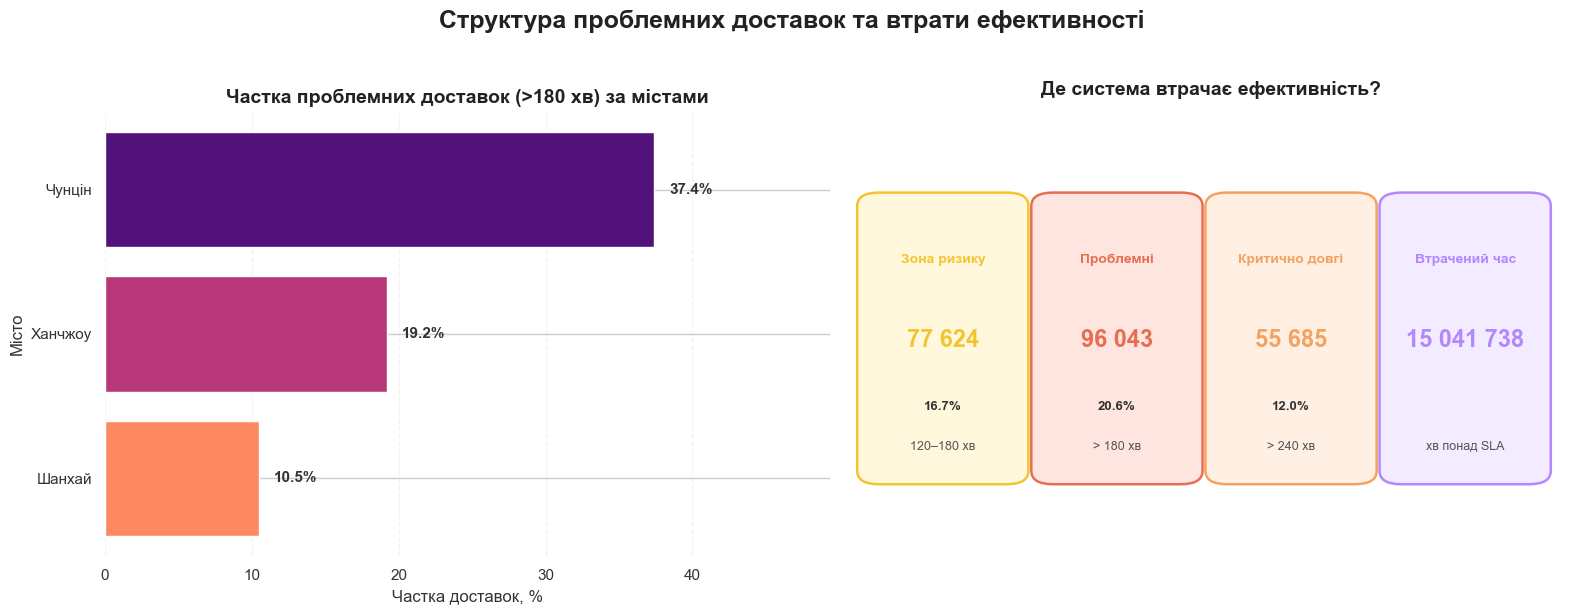

In [16]:
# Розрахунок показників проблемних доставок та втрат ефективності

total_orders = len(df)

risk_orders = df[
    df["delivery_duration_min"].between(
        RISK_THRESHOLD,
        PROBLEM_THRESHOLD,
        inclusive="right"
    )
].shape[0]

problem_orders = int(df["is_problem_delivery"].sum())

critical_orders = int(
    (df["delivery_duration_min"] > CRITICAL_THRESHOLD).sum()
)

# Частка проблемних доставок за містами
problem_by_city = (
    df.groupby("city")["is_problem_delivery"]
    .mean()
    .mul(100)
    .round(1)
    .reset_index(name="problem_share_pct")
    .sort_values("problem_share_pct", ascending=False)
)

# Переклад назв міст українською мовою
city_ua = {
    "Chongqing": "Чунцін",
    "Hangzhou": "Ханчжоу",
    "Shanghai": "Шанхай"
}

problem_by_city["city"] = problem_by_city["city"].map(city_ua)

display(problem_by_city)

# Побудова графіка та KPI-карток
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 6),
    facecolor="white"
)

for ax in axes:
    ax.set_facecolor("white")

# Частка проблемних доставок за містами
magma_colors = sns.color_palette("magma", n_colors=len(problem_by_city))

axes[0].barh(
    problem_by_city["city"],
    problem_by_city["problem_share_pct"],
    color=magma_colors
)

axes[0].set_title(
    "Частка проблемних доставок (>180 хв) за містами",
    fontsize=14,
    fontweight="bold",
    color="#222222"
)

axes[0].set_xlabel(
    "Частка доставок, %",
    color="#333333"
)

axes[0].set_ylabel(
    "Місто",
    color="#333333"
)

axes[0].tick_params(colors="#333333")

axes[0].grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

for spine in axes[0].spines.values():
    spine.set_visible(False)

for i, v in enumerate(problem_by_city["problem_share_pct"]):
    axes[0].text(
        v + 1,
        i,
        f"{v:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#333333"
    )

axes[0].set_xlim(
    0,
    problem_by_city["problem_share_pct"].max() + 12
)

axes[0].invert_yaxis()

# KPI-картки втрат ефективності
axes[1].axis("off")

axes[1].set_title(
    "Де система втрачає ефективність?",
    fontsize=14,
    fontweight="bold",
    color="#222222",
    pad=12
)

cards = [
    (
        "Зона ризику",
        risk_orders,
        f"{risk_orders / total_orders * 100:.1f}%",
        "120–180 хв",
        "#f4c430",
        "#fff8dc"
    ),
    (
        "Проблемні",
        problem_orders,
        f"{problem_orders / total_orders * 100:.1f}%",
        "> 180 хв",
        "#e76f51",
        "#ffe5df"
    ),
    (
        "Критично довгі",
        critical_orders,
        f"{critical_orders / total_orders * 100:.1f}%",
        "> 240 хв",
        "#f4a261",
        "#fff0e3"
    ),
    (
        "Втрачений час",
        int(df["delay_minutes"].sum()),
        "",
        "хв понад SLA",
        "#b388ff",
        "#f3ebff"
    ),
]

for i, (title, val, pct, sub, color, bg_color) in enumerate(cards):
    x = 0.03 + i * 0.24

    axes[1].add_patch(
        FancyBboxPatch(
            (x, 0.18),
            0.20,
            0.62,
            boxstyle="round,pad=0.018,rounding_size=0.03",
            facecolor=bg_color,
            edgecolor=color,
            linewidth=1.8,
            transform=axes[1].transAxes
        )
    )

    axes[1].text(
        x + 0.10,
        0.66,
        title,
        ha="center",
        fontsize=10,
        fontweight="bold",
        color=color,
        transform=axes[1].transAxes
    )

    axes[1].text(
        x + 0.10,
        0.47,
        f"{val:,.0f}".replace(",", " "),
        ha="center",
        fontsize=17,
        fontweight="bold",
        color=color,
        transform=axes[1].transAxes
    )

    if pct:
        axes[1].text(
            x + 0.10,
            0.33,
            pct,
            ha="center",
            fontsize=9.5,
            fontweight="bold",
            color="#333333",
            transform=axes[1].transAxes
        )

    axes[1].text(
        x + 0.10,
        0.24,
        sub,
        ha="center",
        fontsize=9,
        color="#555555",
        transform=axes[1].transAxes
    )

plt.suptitle(
    "Структура проблемних доставок та втрати ефективності",
    fontsize=18,
    fontweight="bold",
    color="#222222",
    y=1.02
)

plt.tight_layout()
plt.show()

## Pareto-аналіз часових втрат

### Для визначення найбільш проблемних категорій доставок проведено Pareto-аналіз. Метод дозволяє перевірити принцип 80/20 та встановити, які групи доставок формують основну частину часових втрат у системі.

In [11]:
# Формування таблиці навантаження кур'єрів

courier_load = (
    df.groupby("delivery_user_id")
    .agg(
        delivery_count=("order_id", "count"),
        avg_delivery_time=("delivery_duration_min", "mean"),
        problem_deliveries=("is_problem_delivery", "sum")
    )
    .reset_index()
)

display(courier_load.head())

,delivery_user_id,delivery_count,avg_delivery_time,problem_deliveries
0,0008c2b6a2314db8715301b7eeeebc5a,116,220.672414,65
1,000e98aedd35d5e6b671144eff2975bb,1,188.000000,1
2,0018c46d0ac8c065ffd9b2588f135d5b,32,102.187500,1
3,00230f9acdd3b69b47639b261ef7d3f4,347,94.991354,62
4,00394bab2f015247df56eb56b9a9dd6a,450,173.240000,133


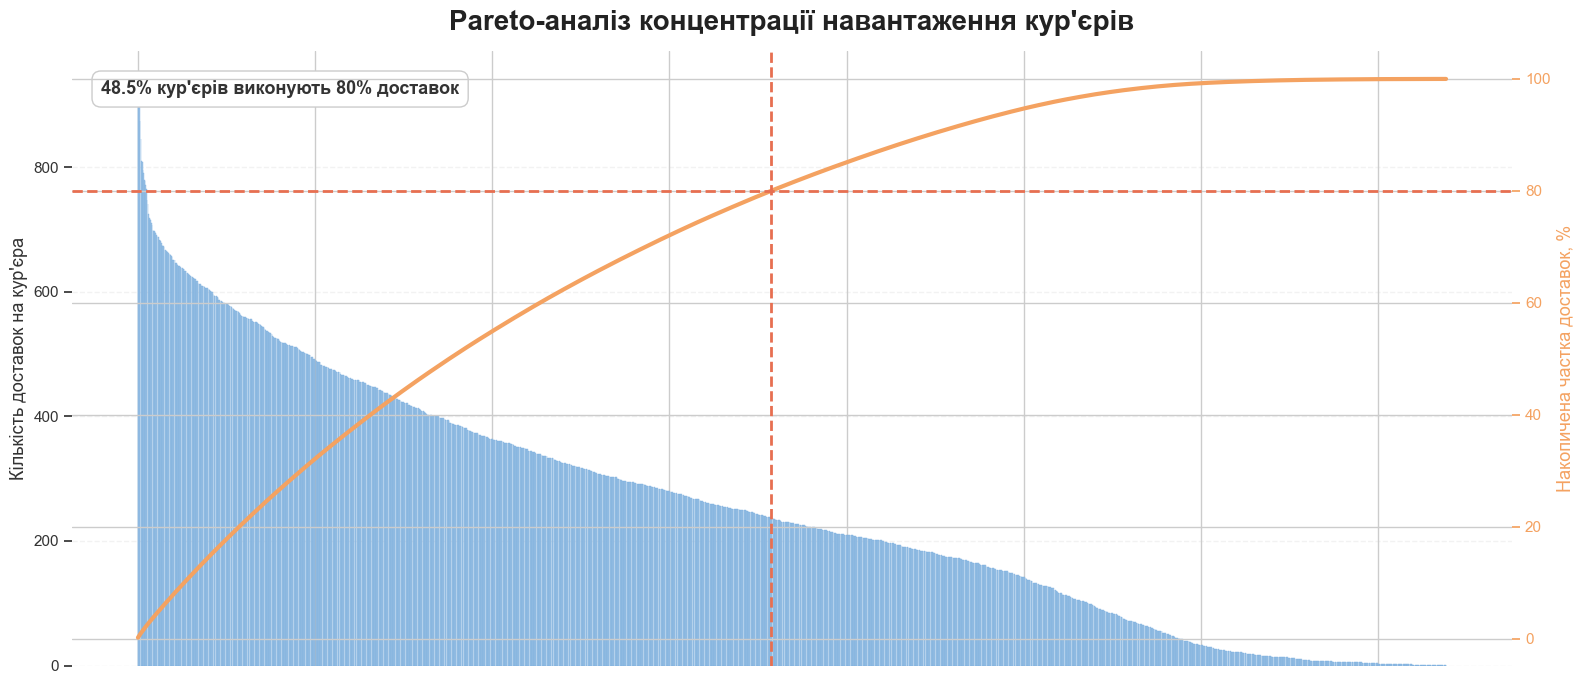

In [12]:
# Pareto-аналіз концентрації навантаження між кур'єрами

pareto_data = (
    courier_load
    .sort_values("delivery_count", ascending=False)
    .reset_index(drop=True)
)

# Розрахунок накопиченої частки доставок
pareto_data["cumulative_pct"] = (
    pareto_data["delivery_count"].cumsum()
    / pareto_data["delivery_count"].sum()
    * 100
)

x = np.arange(len(pareto_data))

fig, ax1 = plt.subplots(figsize=(16, 7), facecolor="white")

ax1.set_facecolor("white")

# Стовпчикова діаграма кількості доставок на одного кур'єра
ax1.bar(
    x,
    pareto_data["delivery_count"],
    color="#a7c7e7",
    edgecolor="#6fa8dc",
    linewidth=0.25,
    alpha=0.95
)

ax1.set_ylabel(
    "Кількість доставок на кур'єра",
    fontsize=13,
    color="#333333"
)

ax1.tick_params(axis="y", colors="#333333")
ax1.tick_params(axis="x", bottom=False, labelbottom=False)

ax1.grid(axis="y", linestyle="--", alpha=0.25)

for spine in ax1.spines.values():
    spine.set_visible(False)

# Лінія Pareto, що відображає накопичену частку доставок
ax2 = ax1.twinx()

ax2.plot(
    x,
    pareto_data["cumulative_pct"],
    color="#f4a261",
    linewidth=3
)

ax2.set_ylabel(
    "Накопичена частка доставок, %",
    fontsize=13,
    color="#f4a261"
)

ax2.tick_params(axis="y", colors="#f4a261")

for spine in ax2.spines.values():
    spine.set_visible(False)

# Позначення порогу 80%
pareto_80_idx = (
    pareto_data[
        pareto_data["cumulative_pct"] >= 80
    ]
    .index[0]
)

ax2.axhline(
    80,
    color="#e76f51",
    linestyle="--",
    linewidth=2
)

ax2.axvline(
    pareto_80_idx,
    color="#e76f51",
    linestyle="--",
    linewidth=2
)

# Текстове пояснення результату Pareto-аналізу
top_share = (pareto_80_idx + 1) / len(pareto_data) * 100

ax1.text(
    0.02,
    0.93,
    f"{top_share:.1f}% кур'єрів виконують 80% доставок",
    transform=ax1.transAxes,
    fontsize=13,
    fontweight="bold",
    color="#333333",
    bbox=dict(
        facecolor="white",
        edgecolor="#cccccc",
        boxstyle="round,pad=0.5"
    )
)

plt.title(
    "Pareto-аналіз концентрації навантаження кур'єрів",
    fontsize=20,
    fontweight="bold",
    color="#222222",
    pad=15
)

plt.tight_layout()
plt.show()

In [17]:
# Розрахунок показників нерівномірності навантаження кур'єрів

courier_load = (
    df.groupby("delivery_user_id")
    .agg(
        delivery_count=("order_id", "count")
    )
    .reset_index()
)

total_deliveries = df["order_id"].count()
unique_couriers = df["delivery_user_id"].nunique()

mean_workload = courier_load["delivery_count"].mean()
median_workload = courier_load["delivery_count"].median()
max_workload = courier_load["delivery_count"].max()

workload_inequality_coef = max_workload / median_workload

workload_table = pd.DataFrame({
    "Показник": [
        "Загальна кількість доставок",
        "Кількість унікальних кур'єрів",
        "Середнє навантаження WL",
        "Медіанне навантаження",
        "Максимальне навантаження",
        "K_нерівн = WL_max / WL_med"
    ],
    "Значення": [
        f"{total_deliveries:,.0f}".replace(",", " "),
        f"{unique_couriers:,.0f}".replace(",", " "),
        f"{mean_workload:.0f} дост/кур'єр",
        f"{median_workload:.0f} дост/кур'єр",
        f"{max_workload:.0f} дост/кур'єр",
        f"{workload_inequality_coef:.2f}"
    ],
    "Інтерпретація": [
        "Весь аналітичний масив",
        "За усіма трьома містами",
        "Середній рівень навантаження",
        "Типовий кур'єр",
        "Найбільш завантажений кур'єр",
        f"Перевищення медіани на {(workload_inequality_coef - 1) * 100:.0f}%"
    ]
})

display(workload_table)

,Показник,Значення,Інтерпретація
0,Загальна кількість доставок,465 384,Весь аналітичний масив
1,Кількість унікальних кур'єрів,1 847,За усіма трьома містами
2,Середнє навантаження WL,252 дост/кур'єр,Середній рівень навантаження
3,Медіанне навантаження,229 дост/кур'єр,Типовий кур'єр
4,Максимальне навантаження,940 дост/кур'єр,Найбільш завантажений кур'єр
5,K_нерівн = WL_max / WL_med,4.10,Перевищення медіани на 310%


In [18]:
print("N =", total_deliveries)
print("M =", unique_couriers)
print("WL = N / M =", round(total_deliveries / unique_couriers, 2))
print("WL mean =", round(mean_workload, 2))
print("WL median =", median_workload)
print("WL max =", max_workload)
print("K нерівн =", round(workload_inequality_coef, 2))

N = 465384
M = 1847
WL = N / M = 251.97
WL mean = 251.97
WL median = 229.0
WL max = 940
K нерівн = 4.1


In [19]:
p95_workload = courier_load["delivery_count"].quantile(0.95)

print("95-й перцентиль =", p95_workload)

print(
    "K95 =",
    round(p95_workload / median_workload, 2)
)

95-й перцентиль = 609.6999999999998
K95 = 2.66


In [20]:
mean_time = df["delivery_duration_min"].mean()

q_base = 60 / mean_time

q_opt = 60 / (mean_time * 0.85)

growth_pct = (q_opt - q_base) / q_base * 100

print("Середній час =", round(mean_time, 2))
print("Q базовий =", round(q_base, 3))
print("Q оптимізований =", round(q_opt, 3))
print("Приріст =", round(growth_pct, 2), "%")

Середній час = 132.76
Q базовий = 0.452
Q оптимізований = 0.532
Приріст = 17.65 %


## Просторовий аналіз проблемних доставок

### Для виявлення зон концентрації понаднормативних доставок побудовано теплові карти за містами. Візуалізація дає змогу оцінити просторовий розподіл проблемних доставок та визначити потенційні ділянки, де транспортно-технологічний процес потребує оптимізації.

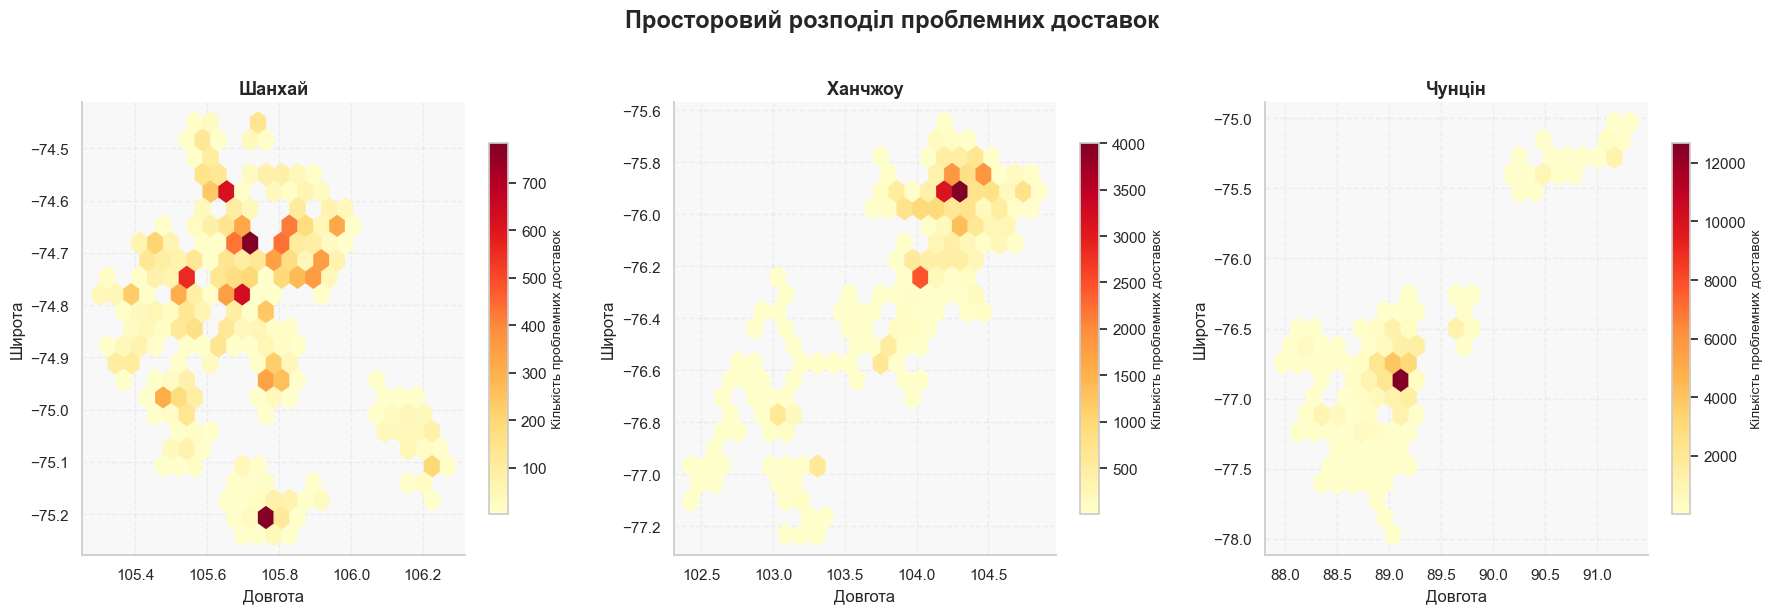

In [22]:
# Просторовий розподіл проблемних доставок за містами

city_ua = {
    "Shanghai": "Шанхай",
    "Hangzhou": "Ханчжоу",
    "Chongqing": "Чунцін"
}

df["city_ua"] = df["city"].map(city_ua)

cities = ["Шанхай", "Ханчжоу", "Чунцін"]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

for ax, city in zip(axes, cities):

    city_df = df[
        (df["city_ua"] == city) &
        (df["is_problem_delivery"] == True)
    ].copy()

    city_df = city_df.dropna(
        subset=["poi_lng_clean", "poi_lat_clean"]
    )

    hb = ax.hexbin(
        city_df["poi_lng_clean"],
        city_df["poi_lat_clean"],
        gridsize=22,
        cmap="YlOrRd",
        mincnt=1,
        linewidths=0.25
    )

    ax.set_title(city, fontsize=13, fontweight="bold")
    ax.set_xlabel("Довгота")
    ax.set_ylabel("Широта")

    ax.set_facecolor("#f8f8f8")
    ax.grid(alpha=0.25, linestyle="--")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    cb = fig.colorbar(hb, ax=ax, shrink=0.82)
    cb.set_label("Кількість проблемних доставок", fontsize=10)

plt.suptitle(
    "Просторовий розподіл проблемних доставок",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

# 2.4. Економічний аналіз втрат та сценарне моделювання

Показники часових та грошових втрат від понаднормативних затримок

In [24]:
city_ua = {
    "Hangzhou": "Ханчжоу",
    "Shanghai": "Шанхай",
    "Chongqing": "Чунцін"
}

loss_table["Місто"] = loss_table["city"].map(city_ua)

result = loss_table[[
    "Місто",
    "total_delay_min",
    "total_delay_hours",
    "total_delay_usd",
    "loss_share_pct"
]].copy()

result.columns = [
    "Місто",
    "Загальна затримка, хв",
    "Загальна затримка, год",
    "Грошові втрати, USD",
    "Частка від загальних, %"
]

display(result)

,Місто,"Загальна затримка, хв","Загальна затримка, год","Грошові втрати, USD","Частка від загальних, %"
0,Чунцін,8100405.0,135007.0,337516.875000,53.9
1,Ханчжоу,5002507.0,83375.0,208437.791667,33.3
2,Шанхай,1938826.0,32314.0,80784.416667,12.9


,city,total_deliveries,total_cost_usd,delay_cost_usd,avg_delivery_cost_usd,delay_cost_pct
0,Chongqing,115990,930911.166667,337516.875000,8.03,36.3
1,Hangzhou,184346,979742.458333,208437.791667,5.31,21.3
2,Shanghai,165048,663682.875000,80784.416667,4.02,12.2


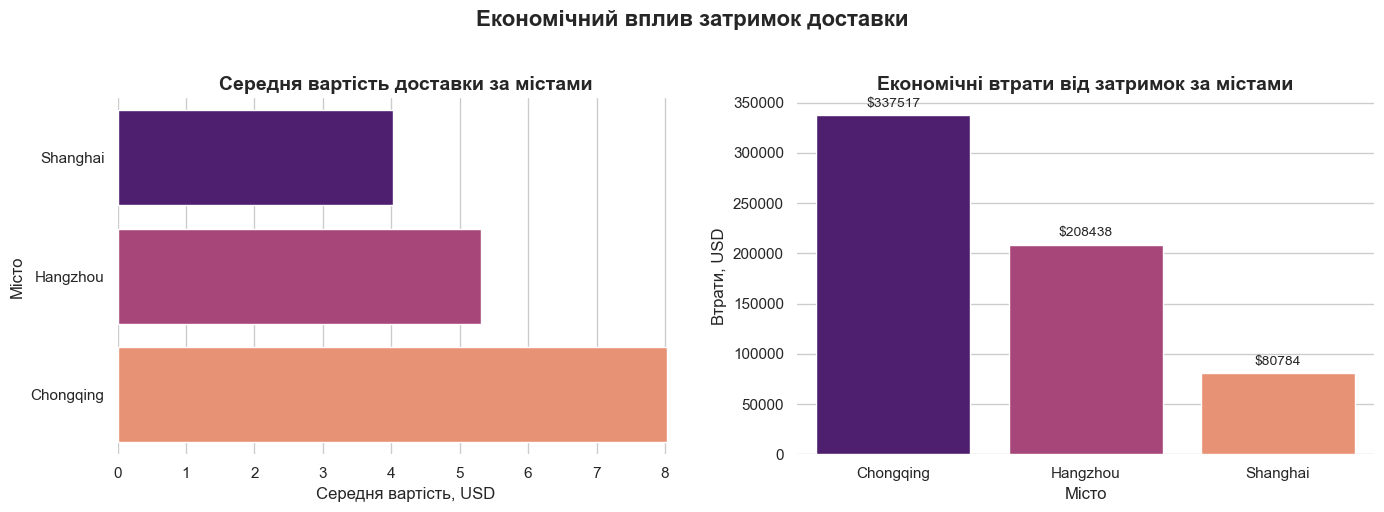

Загальні економічні втрати від затримок: $626,739.08
Середня частка втрат від затримок у загальній вартості доставок: 23.3%


In [13]:
# Розрахунок показників вартості доставки та економічних втрат

city_costs = (
    df.groupby("city")
    .agg(
        total_deliveries=("order_id", "count"),
        total_cost_usd=("delivery_cost_usd", "sum"),
        delay_cost_usd=("delay_cost_usd", "sum")
    )
    .reset_index()
)

# Розрахунок середньої вартості доставки та частки втрат від затримок
city_costs["avg_delivery_cost_usd"] = (
    city_costs["total_cost_usd"] / city_costs["total_deliveries"]
).round(2)

city_costs["delay_cost_pct"] = (
    city_costs["delay_cost_usd"] / city_costs["total_cost_usd"] * 100
).round(1)

display(city_costs)

# Побудова порівняльних діаграм економічних показників
city_costs_s = city_costs.sort_values("avg_delivery_cost_usd", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    sns.despine(ax=ax, left=True, bottom=True)

# Середня вартість доставки за містами
sns.barplot(
    data=city_costs_s,
    y="city",
    x="avg_delivery_cost_usd",
    hue="city",
    palette="magma",
    dodge=False,
    ax=axes[0]
)

axes[0].set_title(
    "Середня вартість доставки за містами",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Середня вартість, USD")
axes[0].set_ylabel("Місто")

axes[0].get_legend().remove() if axes[0].get_legend() else None

# Економічні втрати від затримок за містами
delay_s = city_costs.sort_values("delay_cost_usd", ascending=False)

ax_bar = sns.barplot(
    data=delay_s,
    x="city",
    y="delay_cost_usd",
    palette="magma",
    ax=axes[1]
)

for c in axes[1].containers:
    axes[1].bar_label(c, fmt="$%.0f", padding=4, fontsize=10)

axes[1].set_title(
    "Економічні втрати від затримок за містами",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Місто")
axes[1].set_ylabel("Втрати, USD")

plt.suptitle(
    "Економічний вплив затримок доставки",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

# Розрахунок загальних економічних втрат
total_delay_cost = city_costs["delay_cost_usd"].sum()

print(
    f"Загальні економічні втрати від затримок: ${total_delay_cost:,.2f}"
)

print(
    f"Середня частка втрат від затримок у загальній вартості доставок: "
    f"{city_costs['delay_cost_pct'].mean():.1f}%"
)

# 3.2 Кількісний аналіз ефекту оптимізації транспортно-технологічного процесу

Для оцінки потенційного ефекту від удосконалення транспортно-технологічного процесу було проведено сценарне моделювання. Базовий сценарій порівнюється з оптимізованим варіантом, у якому тривалість кожної доставки зменшується на 15%.

Такий підхід дозволяє оцінити, як скорочення часу доставки вплине на ключові показники ефективності системи: середній та медіанний час доставки, варіативність процесу, кількість проблемних доставок, часові та грошові втрати, а також продуктивність кур'єрської мережі.

Для моделювання використано коефіцієнт оптимізації:

$$
T_{опт}=T_i \times 0.85
$$

де:

- $T_i$ — фактична тривалість i-ї доставки;
- $0.85$ — коефіцієнт, що відповідає скороченню часу доставки на 15%;
- $T_{опт}$ — прогнозна тривалість доставки після впровадження оптимізаційних заходів.

Результати сценарного моделювання наведено в таблиці 3.1.

In [25]:
# Перевірка показників до та після оптимізації

before = df.copy()
after = df_opt.copy()

summary_optimization = pd.DataFrame({
    "Показник": [
        "Середній час доставки, хв",
        "Медіанний час доставки, хв",
        "Ст. відхилення σ, хв",
        "Коефіцієнт варіації CV",
        "Середня вартість доставки, USD",
        "Медіанна вартість, USD",
        "Кількість проблемних доставок",
        "Критично довгі доставки (>240 хв)",
        "Сумарні часові втрати, хв",
        "Грошові втрати від затримок, USD",
        "Продуктивність Q, дост/год"
    ],
    "До оптимізації": [
        before["delivery_duration_min"].mean(),
        before["delivery_duration_min"].median(),
        before["delivery_duration_min"].std(),
        before["delivery_duration_min"].std() / before["delivery_duration_min"].mean(),
        before["delivery_cost_usd"].mean(),
        before["delivery_cost_usd"].median(),
        (before["delivery_duration_min"] > PROBLEM_THRESHOLD).sum(),
        (before["delivery_duration_min"] > CRITICAL_THRESHOLD).sum(),
        before["delay_minutes"].sum(),
        before["delay_cost_usd"].sum(),
        60 / before["delivery_duration_min"].mean()
    ],
    "Після оптимізації (-15%)": [
        after["optimized_delivery_time"].mean(),
        after["optimized_delivery_time"].median(),
        after["optimized_delivery_time"].std(),
        after["optimized_delivery_time"].std() / after["optimized_delivery_time"].mean(),
        after["optimized_delivery_cost_usd"].mean(),
        after["optimized_delivery_cost_usd"].median(),
        (after["optimized_delivery_time"] > PROBLEM_THRESHOLD).sum(),
        (after["optimized_delivery_time"] > CRITICAL_THRESHOLD).sum(),
        after["optimized_delay_minutes"].sum(),
        after["optimized_delay_minutes"].sum() / 60 * COURIER_HOUR_RATE_USD,
        60 / after["optimized_delivery_time"].mean()
    ]
})

summary_optimization["Зміна, абс."] = (
    summary_optimization["Після оптимізації (-15%)"] -
    summary_optimization["До оптимізації"]
)

summary_optimization["Зміна, %"] = (
    summary_optimization["Зміна, абс."] /
    summary_optimization["До оптимізації"] *
    100
)

display(summary_optimization.round(2))

,Показник,До оптимізації,Після оптимізації (-15%),"Зміна, абс.","Зміна, %"
0,"Середній час доставки, хв",132.76,112.85,-19.91,-15.00
1,"Медіанний час доставки, хв",92.00,78.20,-13.80,-15.00
2,"Ст. відхилення σ, хв",141.43,120.22,-21.21,-15.00
3,Коефіцієнт варіації CV,1.07,1.07,0.00,0.00
4,"Середня вартість доставки, USD",5.53,4.70,-0.83,-15.00
5,"Медіанна вартість, USD",3.83,3.26,-0.57,-15.00
6,Кількість проблемних доставок,96043.00,71582.00,-24461.00,-25.47
7,Критично довгі доставки (>240 хв),55685.00,41585.00,-14100.00,-25.32
8,"Сумарні часові втрати, хв",15041738.00,10538189.35,-4503548.65,-29.94
9,"Грошові втрати від затримок, USD",626739.08,439091.22,-187647.86,-29.94


Аналіз результатів показує, що навіть відносно невелике скорочення часу доставки на 15% забезпечує суттєве покращення більшості ключових показників ефективності. Найбільш помітний ефект спостерігається для проблемних доставок і понаднормативних затримок, оскільки частина замовлень переходить із категорії порушення SLA до категорії нормативного виконання.

Крім прямого скорочення операційних витрат, оптимізація призводить до зростання продуктивності системи доставки та збільшення потенційної пропускної здатності кур'єрської мережі без залучення додаткових ресурсів. Це підтверджує доцільність впровадження заходів, спрямованих на скорочення часу виконання доставки.

In [27]:
before_problem = (df["delivery_duration_min"] > 180).sum()

after_problem = (
    df_opt["optimized_delivery_time"] > 180
).sum()

saved_problem = before_problem - after_problem

print("До:", before_problem)
print("Після:", after_problem)
print("Різниця:", saved_problem)

До: 96043
Після: 71582
Різниця: 24461


In [28]:
print("Проблемні доставки:")
print((df["delivery_duration_min"] > 180).sum())
print((df_opt["optimized_delivery_time"] > 180).sum())

print("\nКритично довгі:")
print((df["delivery_duration_min"] > 240).sum())
print((df_opt["optimized_delivery_time"] > 240).sum())

print("\nВтрачений час:")
print(round(df["delay_minutes"].sum()))
print(round(df_opt["optimized_delay_minutes"].sum()))

Проблемні доставки:
96043
71582

Критично довгі:
55685
41585

Втрачений час:
15041738
10538189


Для наочного пояснення механізму скорочення понаднормативних затримок наведено умовний приклад доставки тривалістю 250 хвилин. Після застосування коефіцієнта оптимізації 0,85 загальна тривалість доставки скорочується до 212,5 хвилини, а понаднормативна затримка зменшується з 70 до 32,5 хвилини.

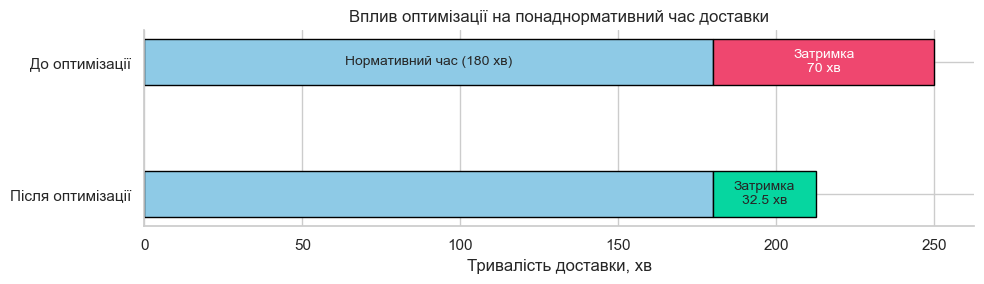

In [29]:
# Вихідні параметри прикладу

norm_limit = 180

before_total = 250
after_total = 212.5

before_delay = before_total - norm_limit
after_delay = after_total - norm_limit

fig, ax = plt.subplots(figsize=(10, 3))

# До оптимізації

ax.barh(
    y=1,
    width=norm_limit,
    color="#8ecae6",
    edgecolor="black",
    height=0.35
)

ax.barh(
    y=1,
    width=before_delay,
    left=norm_limit,
    color="#ef476f",
    edgecolor="black",
    height=0.35
)

# Після оптимізації

ax.barh(
    y=0,
    width=norm_limit,
    color="#8ecae6",
    edgecolor="black",
    height=0.35
)

ax.barh(
    y=0,
    width=after_delay,
    left=norm_limit,
    color="#06d6a0",
    edgecolor="black",
    height=0.35
)

# Текстові підписи

ax.text(
    90,
    1,
    "Нормативний час (180 хв)",
    ha="center",
    va="center",
    fontsize=10
)

ax.text(
    norm_limit + before_delay / 2,
    1,
    f"Затримка\n{before_delay:.0f} хв",
    ha="center",
    va="center",
    fontsize=10,
    color="white"
)

ax.text(
    norm_limit + after_delay / 2,
    0,
    f"Затримка\n{after_delay:.1f} хв",
    ha="center",
    va="center",
    fontsize=10
)

# Оформлення осей та заголовка

ax.set_yticks([1, 0])

ax.set_yticklabels([
    "До оптимізації",
    "Після оптимізації"
])

ax.set_xlabel("Тривалість доставки, хв")

ax.set_title(
    "Вплив оптимізації на понаднормативний час доставки"
)

# Оформлення графіка

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# 3.3. Аналіз пропускної здатності системи та воронка ефективності

### Для оцінки пропускної здатності системи побудовано воронку ефективності доставки. Вона показує співвідношення між загальною кількістю доставок, доставками в межах нормативу, доставками швидше медіанного часу та проблемними доставками, які потребують операційного покращення.

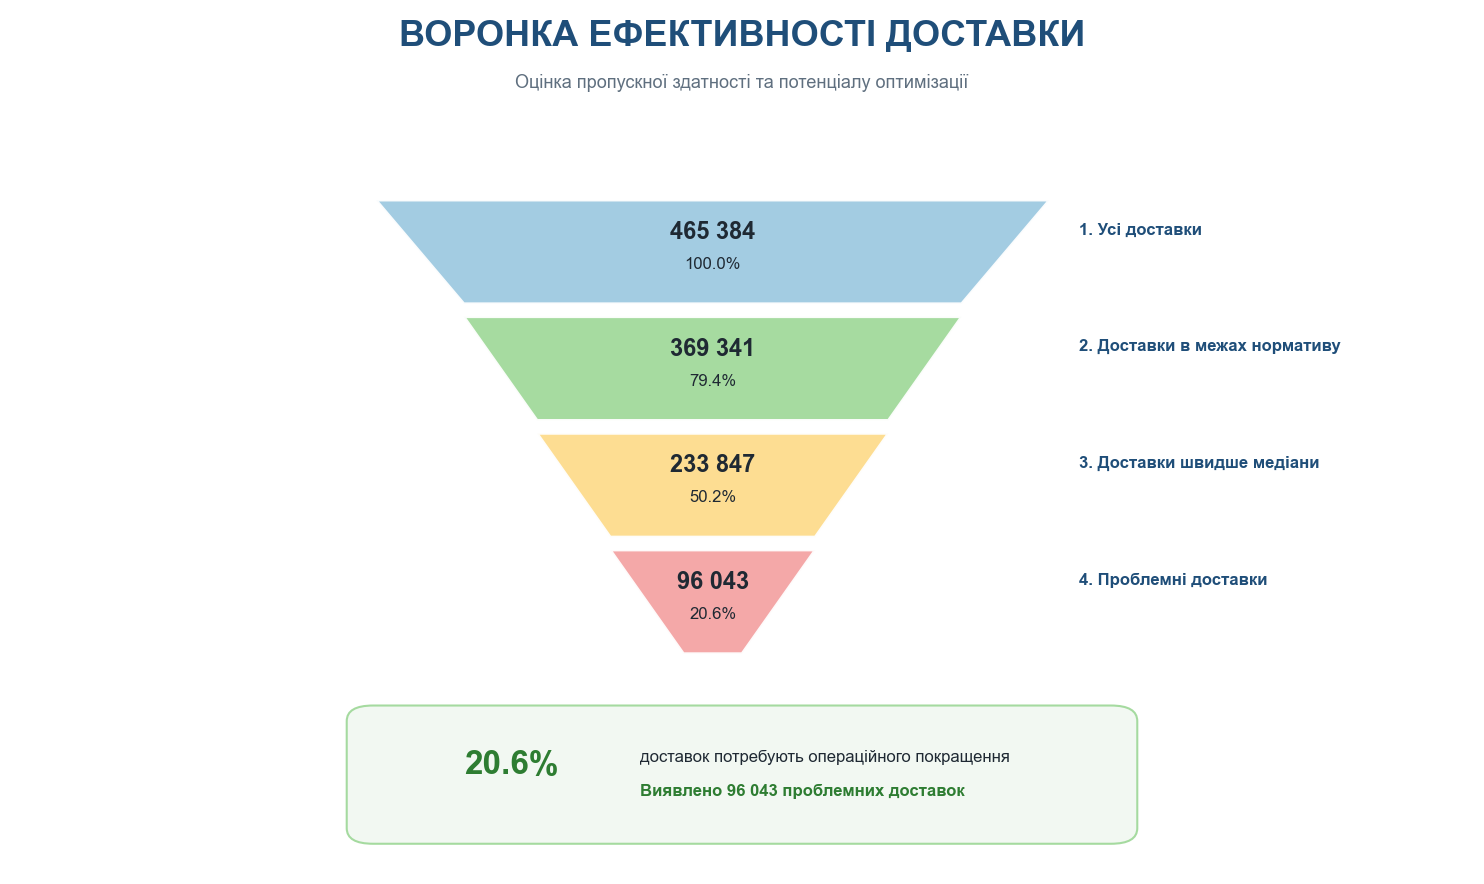

In [30]:
# Побудова воронки ефективності доставки

successful_orders = total_orders - problem_orders
fast_orders = int((df["delivery_duration_min"] <= median_time).sum())

funnel_data = [
    ("Усі доставки", total_orders, 100.0),
    ("Доставки в межах нормативу", successful_orders, successful_orders / total_orders * 100),
    ("Доставки швидше медіани", fast_orders, fast_orders / total_orders * 100),
    ("Проблемні доставки", problem_orders, problem_orders / total_orders * 100),
]

funnel_colors = ["#9ecae1", "#a1d99b", "#fddc8c", "#f4a3a3"]
widths = [0.46, 0.34, 0.24, 0.14]

fig, ax = plt.subplots(figsize=(15, 9), facecolor="white")
ax.set_facecolor("white")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

ax.text(
    0.5, 0.96,
    "ВОРОНКА ЕФЕКТИВНОСТІ ДОСТАВКИ",
    ha="center",
    fontsize=26,
    fontweight="bold",
    color="#1f4e79"
)

ax.text(
    0.5, 0.91,
    "Оцінка пропускної здатності та потенціалу оптимізації",
    ha="center",
    fontsize=13,
    color="#5f6f7f"
)

cx, h, gap, sy = 0.48, 0.12, 0.015, 0.78

for i, ((label, val, pct), color) in enumerate(zip(funnel_data, funnel_colors)):
    yt = sy - i * (h + gap)
    yb = yt - h
    wt = widths[i]
    wb = widths[i + 1] if i < len(widths) - 1 else 0.04

    pts = [
        [cx - wt / 2, yt],
        [cx + wt / 2, yt],
        [cx + wb / 2, yb],
        [cx - wb / 2, yb]
    ]

    ax.add_patch(
        Polygon(
            pts,
            facecolor=color,
            edgecolor="#ffffff",
            lw=2,
            alpha=0.95
        )
    )

    ax.text(
        cx,
        (yt + yb) / 2 + 0.015,
        f"{val:,.0f}".replace(",", " "),
        ha="center",
        fontsize=17,
        fontweight="bold",
        color="#1f2933"
    )

    ax.text(
        cx,
        (yt + yb) / 2 - 0.02,
        f"{pct:.1f}%",
        ha="center",
        fontsize=12,
        color="#1f2933"
    )

    ax.text(
        0.73,
        (yt + yb) / 2 + 0.02,
        f"{i + 1}. {label}",
        ha="left",
        fontsize=12,
        fontweight="bold",
        color="#1f4e79"
    )

# Інформаційний блок щодо частки проблемних доставок
capacity_growth_pct = problem_orders / total_orders * 100

ax.add_patch(
    FancyBboxPatch(
        (0.25, 0.055),
        0.50,
        0.12,
        boxstyle="round,pad=0.02,rounding_size=0.018",
        facecolor="#f2f8f2",
        edgecolor="#a1d99b",
        linewidth=1.5,
        alpha=0.95
    )
)

ax.text(
    0.31,
    0.125,
    f"{capacity_growth_pct:.1f}%",
    fontsize=24,
    fontweight="bold",
    color="#2e7d32",
    ha="left",
    va="center"
)

ax.text(
    0.43,
    0.135,
    "доставок потребують операційного покращення",
    fontsize=12,
    color="#1f2933",
    ha="left",
    va="center"
)

ax.text(
    0.43,
    0.095,
    f"Виявлено {problem_orders:,} проблемних доставок".replace(",", " "),
    fontsize=12,
    fontweight="bold",
    color="#2e7d32",
    ha="left",
    va="center"
)

plt.tight_layout()
plt.show()

## Зведена оцінка економічного ефекту від оптимізації транспортно-технологічного процесу

In [31]:
print("Середня вартість ДО:", round(df["delivery_cost_usd"].mean(), 2))
print("Середня вартість ПІСЛЯ:", round(df_opt["optimized_delivery_cost_usd"].mean(), 2))

direct_saving = (
    df["delivery_cost_usd"].mean()
    - df_opt["optimized_delivery_cost_usd"].mean()
) * len(df)

print("Пряма економія витрат:", round(direct_saving, 2))

Середня вартість ДО: 5.53
Середня вартість ПІСЛЯ: 4.7
Пряма економія витрат: 386150.48


Перевірка скорочення витрат від затримок:

In [32]:
before_delay_cost = df["delay_cost_usd"].sum()

after_delay_cost = (
    df_opt["optimized_delay_minutes"].sum()
    / 60
    * COURIER_HOUR_RATE_USD
)

print("До:", round(before_delay_cost, 2))
print("Після:", round(after_delay_cost, 2))
print("Економія:", round(before_delay_cost - after_delay_cost, 2))

До: 626739.08
Після: 439091.22
Економія: 187647.86


Перевірка потенційного додаткового доходу:

In [34]:
saved_time = (
    df["delay_minutes"].sum()
    - df_opt["optimized_delay_minutes"].sum()
)

additional_deliveries = saved_time / median_time

potential_revenue = (
    additional_deliveries
    * df_opt["optimized_delivery_cost_usd"].mean()
)

print("Додаткові доставки:", round(additional_deliveries))
print("Потенційний дохід:", round(potential_revenue, 2))

Додаткові доставки: 48952
Потенційний дохід: 230165.29


Перевірка скорочення проблемних доставок:

In [35]:
before_problem = (df["delivery_duration_min"] > 180).sum()
after_problem = (df_opt["optimized_delivery_time"] > 180).sum()

print(before_problem)
print(after_problem)
print(before_problem - after_problem)

96043
71582
24461


Перевірка приросту пропускної здатності:

In [36]:
q_before = 60 / df["delivery_duration_min"].mean()
q_after = 60 / df_opt["optimized_delivery_time"].mean()

print("Q до:", q_before)
print("Q після:", q_after)

print(
    "Приріст:",
    (q_after - q_before) / q_before * 100
)

Q до: 0.4519455789870516
Q після: 0.5317006811612373
Приріст: 17.647058823529424


Перевірка стандартного відхилення:

In [37]:
std_before = df["delivery_duration_min"].std()
std_after = df_opt["optimized_delivery_time"].std()

print("До:", round(std_before, 2))
print("Після:", round(std_after, 2))

До: 141.43
Після: 120.22


Сума вартості проблемних доставок дає загальний обсяг грошових втрат від понаднормативної роботи. Після оптимізації цей показник скорочується непропорційно більше, ніж 15%. 

In [38]:
saved_time = (
    df["delay_minutes"].sum()
    - df_opt["optimized_delay_minutes"].sum()
)

saved_hours = saved_time / 60

additional_deliveries = saved_time / median_time

print("Зекономлений час, хв =", round(saved_time))
print("Зекономлений час, год =", round(saved_hours))
print("Медіанний час доставки =", median_time)
print("Додаткові доставки =", round(additional_deliveries))

Зекономлений час, хв = 4503549
Зекономлений час, год = 75059
Медіанний час доставки = 92.0
Додаткові доставки = 48952
